In [2]:
# Developing STIV slope detection code from Fujita et al. 2019 https://doi.org/10.1007/s10652-018-9651-3
import PyPlot as plt
import HDF5
import Statistics
import Images
import LinearAlgebra
import FFTW

function centered_moving_average(vs, n)
    len = length(vs)
    vs_extended = vcat(vs[end-div(n,2)+1:end], vs, vs[1:div(n,2)])  # Wrap around
    return [sum(@view vs_extended[i:(i+n-1)]) / n for i in 1:len]
end

function find_theta_max(sinogram, angles)
    # Compute variance along each angle θ (columns of sinogram)
    var_theta = vec(sum(sinogram.^2, dims=1))  # Variance proxy

    # Find θ_max as the angle with the highest variance
    idx_max = argmax(var_theta)
    θ_max = angles[idx_max]  # Extract angle at max variance

    # Convert to degrees for interpretation
    return rad2deg(θ_max)
end


find_theta_max (generic function with 1 method)

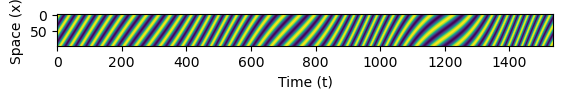

In [3]:
# Generate synthetic data from Drew et al. 2009 DOI: 10.1007/s10827-009-0159-1

len_t = 1536
len_x = 97 # Modified from 96 to have odd number

x = range(1, len_x; length = len_x)  # Spatial positions
t = range(1, len_t; length = len_t)  # Time points

phi_x = 2π * (1/50) .* x  # Spatial phase
omega_t = 30 .+ sin.(0.0132 .* t)  # Time-dependent frequency

# Convert to 2D arrays for proper broadcasting
X = repeat(x', len_t, 1)  # Shape (len_t, len_x)
T = repeat(t, 1, len_x)  # Shape (len_t, len_x)

# Compute F_xt with proper spatial and temporal variations
F_xt = 0.5 .* (1 .+ sin.(2π/1000 .* omega_t .* T .+ phi_x'))'

# Plot
plt.close()
plt.imshow(F_xt, cmap="viridis")
plt.ylabel("Space (x)")
plt.xlabel("Time (t)")
# plt.colorbar(label="Intensity")
plt.gcf()



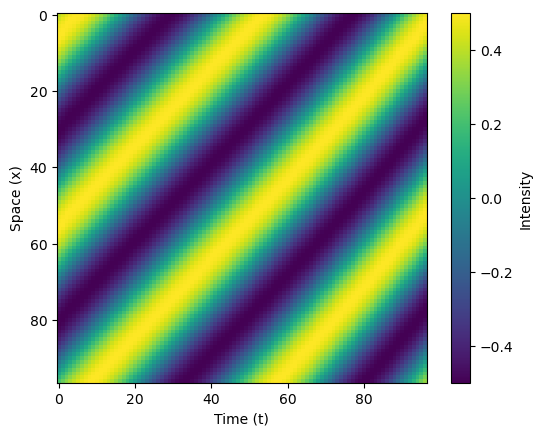

In [119]:
# Select square part of image to test on
# Start points to test: 1, 700, 1150, 1400\
F_xt_start = 700

F_xt_sq = F_xt[:,F_xt_start:F_xt_start+len_x-1]
F_xt_sq .-= Statistics.mean(F_xt_sq) # Subtracting mean from data important for accurate spectra

plt.close("all")
plt.imshow(F_xt_sq, cmap="viridis")
plt.ylabel("Space (x)")
plt.xlabel("Time (t)")
plt.colorbar(label="Intensity")
plt.gcf()


dataset -> HDF5.Dataset


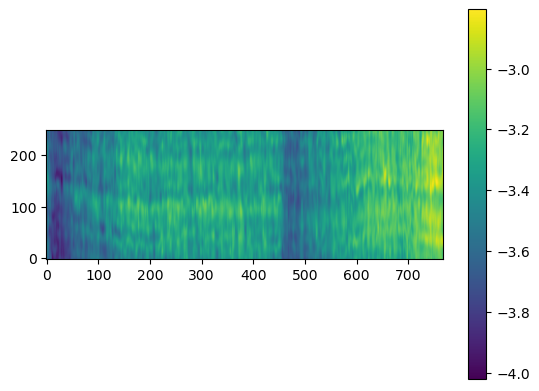

In [3]:
# Import real STIV image

STIV_path = raw"/Users/evanheberlein/Library/CloudStorage/Box-Box/Cornell/Fall_2021/Carp_UAV/STIV_export/flightA_STIV_interp2.h5"
STIV_file = HDF5.h5open(STIV_path, "r")

for name in keys(STIV_file)
    println(name, " -> ", typeof(STIV_file[name]))
end

STIV_image = HDF5.read(STIV_file["dataset"])'

HDF5.close(STIV_file)

plt.figure()
plt.imshow(STIV_image, origin = "lower")
plt.colorbar()
plt.gcf()

# STIV_ratio = size(STIV_image)[2]/size(STIV_image)[1]

In [4]:
STIV_start = 1
STIV_sq_rows = range(1, size(STIV_image)[1]-1)
STIV_sq_cols = range(STIV_start,STIV_start + size(STIV_image)[1] - 2)

STIV_sq = STIV_image[STIV_sq_rows, STIV_sq_cols]

plt.close("all")
plt.imshow(STIV_sq, cmap="viridis")
plt.ylabel("Space (x)")
plt.xlabel("Time (t)")
plt.colorbar(label="Intensity")
plt.gcf()

size(STIV_sq)

(248, 248)

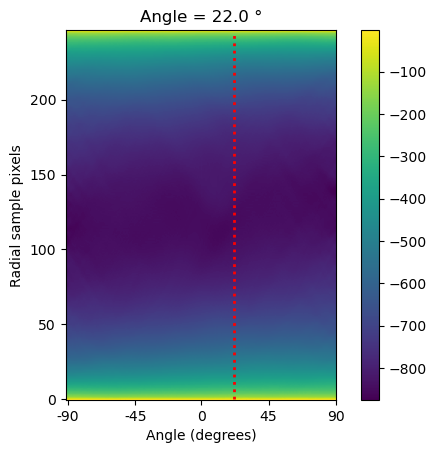

In [5]:
import RadonKA

img = STIV_sq
angles = deg2rad.(range(0, step = 1, length = 180))
radon_img = RadonKA.radon(img, angles)

x_vector = collect(angles) .* (180 / π)  # Convert radians to degrees
x_ticks = -90:45:90

theta_max = 90 - find_theta_max(radon_img, angles) 

# Define custom x-ticks at intervals of 45
x_ticks = -90:45:90  # Custom ticks at -90, -45, 0, 45, 90

# Map the x-tick values to pixel indices (assuming the image width corresponds to 180 degrees)
image_width = size(radon_img, 2)  # Get the number of columns (x-dimension)
x_tick_positions = round.(Int, LinRange(1, image_width, length(x_ticks)))

plt.close("all")
plt.figure()
plt.imshow(radon_img, origin = "lower")
plt.title("Angle = $theta_max °")
plt.colorbar()
plt.plot([theta_max+90, theta_max+90], [0, size(radon_img, 1)-1], color="red", linestyle=":", lw=2)
plt.xticks(x_tick_positions, x_ticks)
plt.xlabel("Angle (degrees)")
plt.ylabel("Radial sample pixels")
plt.gcf()


# size(radon_img)
# x_ticks[3]

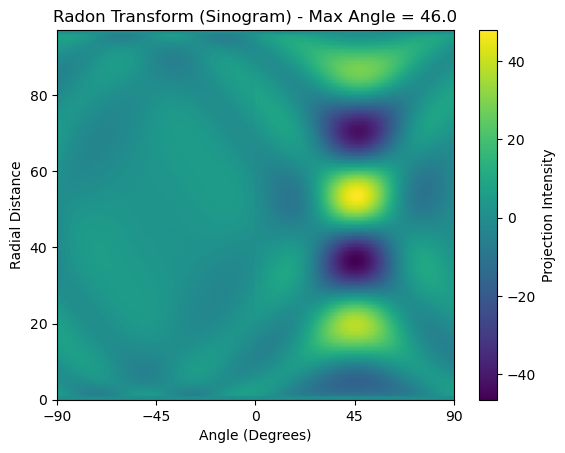

In [168]:

# Compute Radon Transform
img = F_xt_sq
angles = deg2rad.(range(1, step=1, length=180))  # Convert degrees to radians
radon_img = RadonKA.radon(img, angles)

# Convert angles to degrees for x-axis representation
x_vector = collect(angles) .* (180 / π)  # Convert radians to degrees
x_ticks = -90:45:90  # Set x-axis ticks in degrees

# Find dominant angle and shift range
theta_max = find_theta_max(radon_img, angles) - 90  # Adjust to -90 to 90 range

# Plot Sinogram (Radon Transform)
plt.figure()
plt.imshow(radon_img, extent=[-90, 90, 0, size(radon_img, 1)], aspect="auto")
plt.title("Radon Transform (Sinogram) - Max Angle = $theta_max")
plt.colorbar(label="Projection Intensity")
plt.xticks(x_ticks)
plt.xlabel("Angle (Degrees)")
plt.ylabel("Radial Distance")
plt.gcf()

In [169]:
angles = deg2rad.(range(1, step = 1, length = 180))
# length(angles)
# angles[50]

180-element Vector{Float64}:
 0.017453292519943295
 0.03490658503988659
 0.05235987755982989
 0.06981317007977318
 0.08726646259971647
 0.10471975511965978
 0.12217304763960307
 0.13962634015954636
 0.15707963267948966
 0.17453292519943295
 ⋮
 3.001966313430247
 3.01941960595019
 3.036872898470133
 3.0543261909900767
 3.07177948351002
 3.0892327760299634
 3.1066860685499065
 3.12413936106985
 3.141592653589793

In [170]:
F_xt_sq

97×97 Matrix{Float64}:
  0.402358    0.43811     0.466144   …   0.402898    0.442934    0.47302
  0.436464    0.464957    0.485279       0.436909    0.468621    0.489758
  0.463694    0.484478    0.496766       0.464036    0.486925    0.498779
  0.483619    0.496365    0.500427       0.483852    0.497556    0.49994
  0.495923    0.500431    0.496202       0.496044    0.500347    0.493225
  0.500413    0.496611    0.484158   …   0.50042     0.495255    0.478737
  0.497017    0.484967    0.464486       0.496911    0.482358    0.456707
  0.485791    0.465681    0.437495       0.485572    0.461862    0.427481
  0.46691     0.439058    0.403612       0.466582    0.434088    0.391519
  0.440672    0.405518    0.36337        0.44024     0.399475    0.349391
  ⋮                                  ⋱               ⋮          
 -0.271159   -0.213348   -0.151933      -0.270395   -0.204114   -0.132853
 -0.216402   -0.155012   -0.0910451     -0.215582   -0.145319   -0.0714029
 -0.158225   -0.0942251  